# Decision Tree Classifier

A decision tree makes predictions by asking a sequence of yes/no (or threshold) questions about the data, splitting it into smaller and smaller groups until each group is as "pure" as possible (mostly one class). It's essentially a flowchart: "Is `Contract` - Month-to-month? → Is `tenure` < 12? → Predict Churn." No equation at all - just a series of learned rules.

**Why it was required / the purpose:** Logistic Regression's biggest fallback, identified earlier, was its **linear decision boundary** - it can't capture interactions between features (e.g., "high charges AND short tenure AND fiber optic" combining in a non-additive way). A decision tree fixes this directly - it can carve out any shape of decision region by repeatedly splitting on different features, at different thresholds, in different orders, which naturally captures interactions logistic regression structurally cannot.

**How it actually decides where to split (the core intuition):** at each step, the tree tries every possible feature and threshold, and picks whichever split makes the resulting two groups the "purest" - i.e., as close to all-one-class as possible. This purity is measured mathematically using either **Gini impurity** or **entropy** (two different but related formulas for "how mixed is this group").

**Real example fit:** exactly your churn project - a tree might learn: "if `Contract` = Month-to-month AND `tenure` < 6 AND `InternetService` = Fiber optic → high churn risk." This is a genuinely realistic, human-readable rule that a business team could act on directly, which is also a major practical advantage trees have over logistic regression coefficients.



 Example 1 (manual data) and Example 2 (real Telco dataset).

## Decision Tree - Example 1: manual data

In [ ]:
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.tree import DecisionTreeClassifier ,plot_tree 

In [ ]:
tenure = np.array([1,2,5,8,12,20,30,40,50,60]).reshape(-1,1)
churn = np.array([1,1,1,1,0,0,0,0,0,0]) 

In [5]:
model = DecisionTreeClassifier(max_depth=2,random_state=42)
model.fit(tenure,churn)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",2
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

In [ ]:
prediction = model.predict([[15]]) # tenure(stay) , churn (leave ) ----- if tenure is 0 ,so not stay 
print("prediction for tenure=15: ",prediction) # if tenure pred is 0 it  mean will it stay to be our customer for 15 months . 

prediction for tenure=15:  [0]


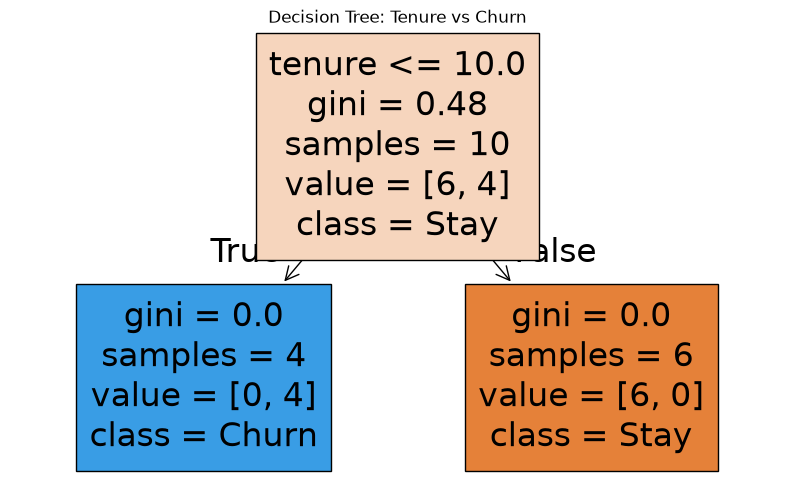

In [8]:
plt.figure(figsize=(10,6))
plot_tree(model, feature_names=["tenure"], class_names=["Stay", "Churn"], filled=True)
plt.title("Decision Tree: Tenure vs Churn")
plt.savefig("../visuals/decision_tree_manual.png")
plt.show()

## Reading the output

**`Prediction for tenure=15: [0]`** - the tree classifies tenure=15 as **class 0 (Stay)**. Tracing it through the diagram: tenure=15 fails the root condition `tenure ≤ 10.0` (15 is NOT ≤ 10), so it goes down the **"False"** branch — landing in the right box, which is 100% "Stay" (gini=0.0). That's why it predicts Stay.

## The tree diagram, box by box

**Root box:** `tenure ≤ 10.0, gini=0.48, samples=10, value=[6,4], class=Stay`
- `samples=10` - all 10 training rows start here
- `value=[6,4]` - 6 rows belong to class 0 (Stay), 4 rows belong to class 1 (Churn) - matches your original data: 4 churned (tenure 1,2,5,8), 6 stayed (tenure 12,20,30,40,50,60)
- `class=Stay` - the majority class in this box (6>4), so if the tree stopped here, it would just guess "Stay" for everyone
- `gini=0.48` - a measure of how "mixed" this group is (explained fully below)

**Left box (True - tenure≤10):** `gini=0.0, samples=4, value=[0,4], class=Churn`
All 4 rows with tenure≤10 (tenure 1,2,5,8) are churners - 0 stayed, 4 churned. Perfectly pure.

**Right box (False - tenure>10):** `gini=0.0, samples=6, value=[6,0], class=Stay`
All 6 rows with tenure>10 (tenure 12,20,30,40,50,60) stayed - 6 stayed, 0 churned. Also perfectly pure.

## Full mathematical breakdown

**Step 1 - Gini impurity formula**
$$Gini = 1 - \sum_{i} p_i^2$$
where $p_i$ is the proportion of each class in that group.

**Step 2 - calculate Gini at the root, by hand**
$$p(\text{Stay}) = 6/10 = 0.6 \qquad p(\text{Churn}) = 4/10 = 0.4$$
$$Gini_{root} = 1 - (0.6^2 + 0.4^2) = 1 - (0.36 + 0.16) = 1 - 0.52 = 0.48$$
Matches the printed `gini=0.48` exactly.

**Step 3 - how the tree finds where to split**
The algorithm tries **every possible threshold**, sitting at the midpoint between each pair of consecutive sorted tenure values: (1.5, 3.5, 6.5, 10, 16, 25, 35, 45, 55). For each candidate threshold, it splits the data into "≤ threshold" and "> threshold" groups, then computes the **weighted average Gini** of the two resulting groups:
$$Gini_{split} = \frac{n_{left}}{n_{total}}Gini_{left} + \frac{n_{right}}{n_{total}}Gini_{right}$$

**Step 4 - testing the winning threshold (tenure=10) by hand**
Left group (tenure≤10): rows with tenure 1,2,5,8 → all churn → $p(\text{Churn})=4/4=1.0$
$$Gini_{left} = 1-(0^2+1^2) = 0$$
Right group (tenure>10): rows with tenure 12,20,30,40,50,60 → all stay → $p(\text{Stay})=6/6=1.0$
$$Gini_{right} = 1-(1^2+0^2) = 0$$
$$Gini_{split} = \frac{4}{10}(0) + \frac{6}{10}(0) = 0$$

**Step 5 - why this specific threshold won**
A weighted Gini of **0** is the absolute best possible outcome - it means the split perfectly separates the two classes with zero mixing left in either group. Every other candidate threshold (1.5, 3.5, 6.5, 16, 25, etc.) would produce a *higher* weighted Gini, since it wouldn't split the data this cleanly. The algorithm compares all candidates and picks whichever minimizes weighted Gini - here, tenure=10 wins outright.

**Step 6 - Information Gain (the value being maximized, framed the other way)**
$$\text{Information Gain} = Gini_{parent} - Gini_{split} = 0.48 - 0 = 0.48$$
This is the maximum possible gain - the split removed *all* remaining impurity in one step.

**Step 7 - why the tree stopped at depth 1, even though `max_depth=2` allowed one more level**
Both child nodes reached `gini=0.0` - meaning each group is already 100% pure (all one class). There's nothing left to split - asking any further question in a perfectly pure group can't improve anything, so the algorithm stops early regardless of the `max_depth` ceiling. This stopping condition (pure node) always overrides depth limits when reached.

**Step 8 - the actual prediction rule this tree learned, in plain English**
"If tenure is 10 months or less → predict Churn. If tenure is more than 10 months → predict Stay." No equation, no probability, no coefficients - just this one clean rule.

**Honest limitation to note here, matching the same caveat from Logistic Regression's manual example:** this dataset had an unrealistically clean split (a hard 8→12 gap with nothing in between), which is exactly why the tree found a perfect gini=0 split so easily. On real data (like Telco, coming next), tenure and churn overlap messily - a tenure=10 customer might churn, a tenure=45 customer might also churn - so expect Gini values that never fully reach 0, and a tree that needs multiple splits, multiple features, and a `max_depth` limit to avoid memorizing noise.



## Decision Tree - Example 2: real Telco dataset

In [3]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv") 

In [8]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [9]:
# Recreate the binary target if it's missing
df["Churn_binary"] = df["Churn"].map({"Yes": 1, "No": 0})

In [10]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(0)  # or df.dropna(subset=["TotalCharges"])

In [12]:
print(df.columns.tolist())
print(df["Churn"].value_counts())

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'Churn_binary']
Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [13]:
X = df[["tenure", "MonthlyCharges", "TotalCharges"]]
y = df["Churn_binary"]

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
model = DecisionTreeClassifier(max_depth=4, random_state=42)
model.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

In [16]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

In [17]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\n Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\n Classification Report:\n", classification_report(y_test, y_pred))
print("\n AUC:", roc_auc_score(y_test, y_proba))

Accuracy: 0.7913413768630234

 Confusion Matrix:
 [[918 118]
 [176 197]]

 Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.89      0.86      1036
           1       0.63      0.53      0.57       373

    accuracy                           0.79      1409
   macro avg       0.73      0.71      0.72      1409
weighted avg       0.78      0.79      0.79      1409


 AUC: 0.8214337470369641


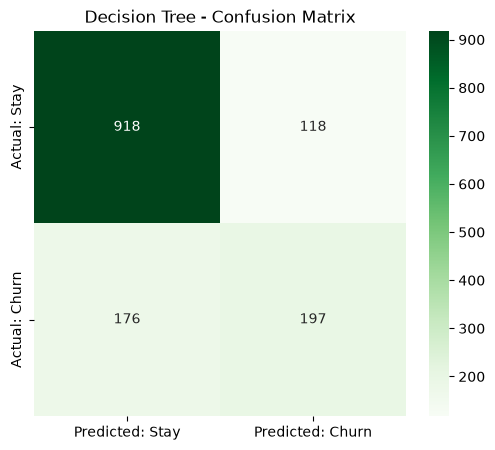

In [18]:
# Confusion matrix heatmap
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Predicted: Stay", "Predicted: Churn"],
            yticklabels=["Actual: Stay", "Actual: Churn"])
plt.title("Decision Tree - Confusion Matrix")
plt.savefig("../visuals/dtree_confusion_matrix.png")
plt.show()

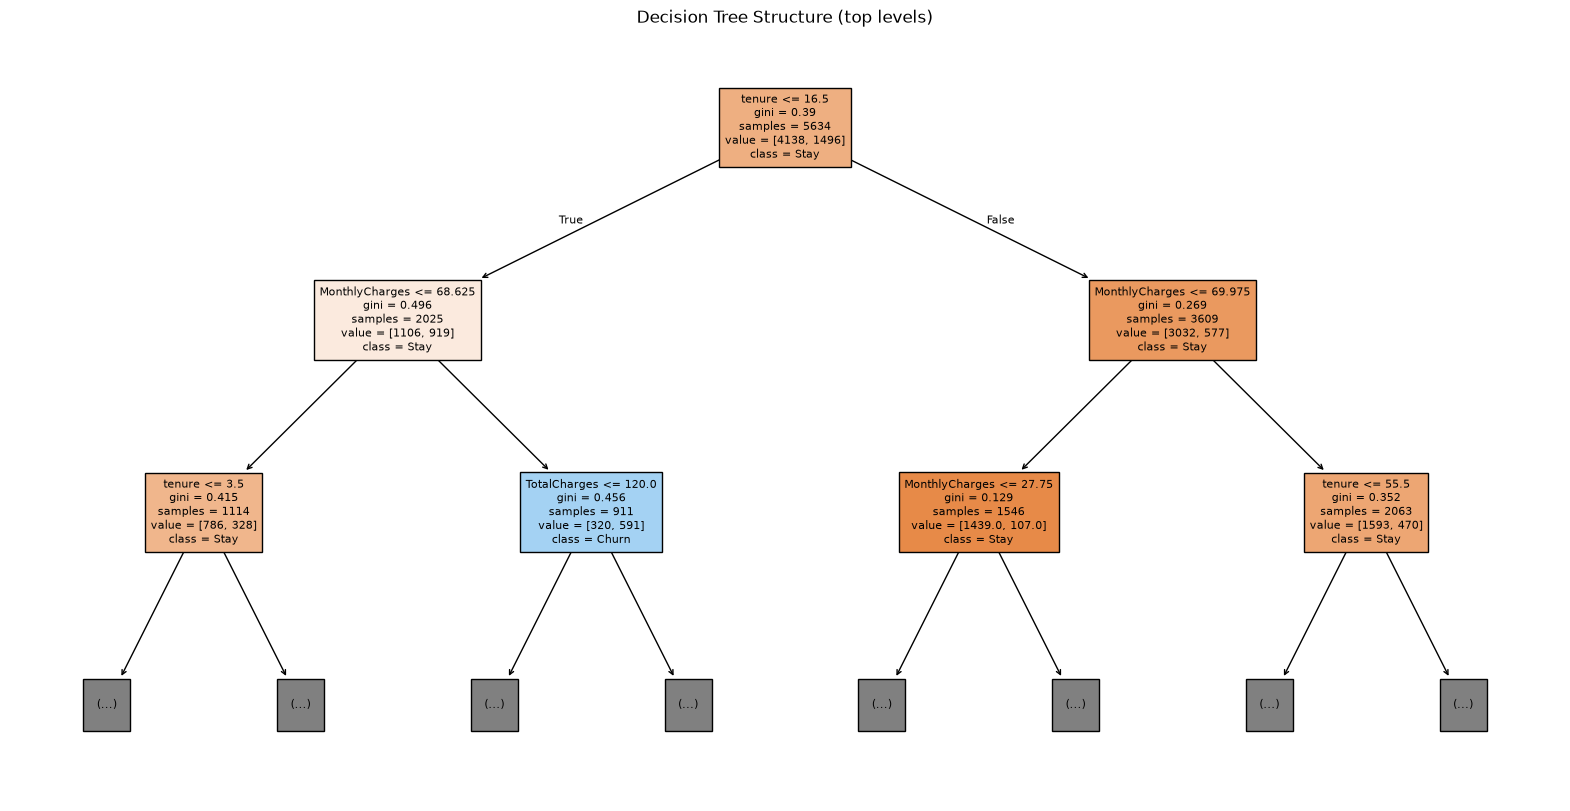

In [19]:
# Tree diagram
plt.figure(figsize=(20, 10))
plot_tree(model, feature_names=["tenure","MonthlyCharges","TotalCharges"],
          class_names=["Stay","Churn"], filled=True, max_depth=2, fontsize=8)
plt.title("Decision Tree Structure (top levels)")
plt.savefig("../visuals/dtree_structure.png")
plt.show()

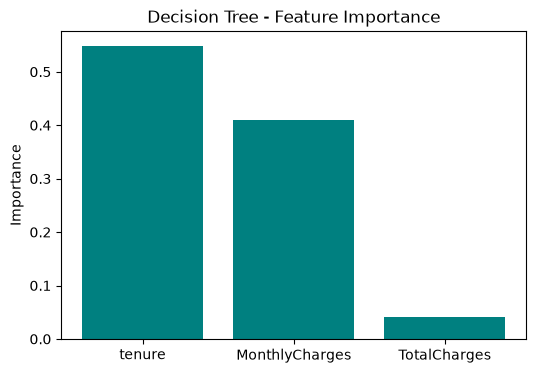

In [20]:
# Feature importance
importances = model.feature_importances_
features = ["tenure", "MonthlyCharges", "TotalCharges"]
plt.figure(figsize=(6,4))
plt.bar(features, importances, color="teal")
plt.title("Decision Tree - Feature Importance")
plt.ylabel("Importance")
plt.savefig("../visuals/dtree_feature_importance.png")
plt.show()

What's new here vs. Example 1:

max_depth=4 - deliberately limited (real data has thousands of rows; an unlimited tree would overfit badly, memorizing near-individual customers)
feature_importances_ - a new concept: tells you which feature the tree relied on most across all its splits, computed from how much each feature reduced Gini impurity overall. Logistic Regression had coefficients for this; trees have importances instead.
plot_tree(..., max_depth=2, ...) - only showing the top 2 levels visually, since a full depth-4 tree with 3 features gets visually cluttered fast

Run this and paste the accuracy, confusion matrix, AUC, and feature importance values — then we'll compare it directly against Logistic Regression's numbers (78% accuracy, 0.80 AUC) to see whether the tree actually improved on the recall weakness.